# Import Library

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Read data (https://www.kaggle.com/datasets/sohaibdevv/consumer-shopping-behavior-and-preference-study-2026/data?select=Consumer_Shopping_Trends_2026+%286%29.csv)

In [2]:
df = pd.read_csv('Consumer_Shopping_Trends_2026.csv')

## Data Preprocessing

In [3]:
pd.set_option('display.max_columns', None)
df.head()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,avg_store_spend,discount_sensitivity,return_frequency,avg_delivery_days,delivery_fee_sensitivity,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,144092,2,3,2,6,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,28421,4,7,4,1,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,128229,9,4,5,3,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,134650,7,0,3,3,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,34122,5,9,2,4,2,5,8,9,7,1,6,Male,Tier 3,Store


In [4]:
df.tail()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,avg_store_spend,discount_sensitivity,return_frequency,avg_delivery_days,delivery_fee_sensitivity,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
11784,67,151087,10.4,4,2.2,2,5,42,4,70860,134990,3,6,3,2,9,9,7,2,8,7,6,Other,Tier 1,Store
11785,60,243273,6.1,10,3.0,3,2,20,14,90420,11059,2,2,6,4,4,7,10,8,2,1,10,Female,Tier 2,Store
11786,53,154729,4.6,13,1.8,8,2,11,15,18700,119055,8,3,4,5,5,9,1,3,4,6,1,Female,Tier 2,Store
11787,65,66116,6.2,3,1.0,1,1,31,0,61475,137980,1,3,6,5,1,7,10,10,2,2,9,Other,Tier 1,Store
11788,34,168023,4.7,11,2.6,4,2,46,7,24532,117484,2,4,7,5,4,4,5,2,5,2,6,Female,Tier 1,Store


In [5]:
df.shape

(11789, 25)

In [6]:
df.columns

Index(['age', 'monthly_income', 'daily_internet_hours',
       'smartphone_usage_years', 'social_media_hours',
       'online_payment_trust_score', 'tech_savvy_score',
       'monthly_online_orders', 'monthly_store_visits', 'avg_online_spend',
       'avg_store_spend', 'discount_sensitivity', 'return_frequency',
       'avg_delivery_days', 'delivery_fee_sensitivity',
       'free_return_importance', 'product_availability_online',
       'impulse_buying_score', 'need_touch_feel_score', 'brand_loyalty_score',
       'environmental_awareness', 'time_pressure_level', 'gender', 'city_tier',
       'shopping_preference'],
      dtype='object')

In [7]:
df.dtypes

age                              int64
monthly_income                   int64
daily_internet_hours           float64
smartphone_usage_years           int64
social_media_hours             float64
online_payment_trust_score       int64
tech_savvy_score                 int64
monthly_online_orders            int64
monthly_store_visits             int64
avg_online_spend                 int64
avg_store_spend                  int64
discount_sensitivity             int64
return_frequency                 int64
avg_delivery_days                int64
delivery_fee_sensitivity         int64
free_return_importance           int64
product_availability_online      int64
impulse_buying_score             int64
need_touch_feel_score            int64
brand_loyalty_score              int64
environmental_awareness          int64
time_pressure_level              int64
gender                          object
city_tier                       object
shopping_preference             object
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11789 entries, 0 to 11788
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          11789 non-null  int64  
 1   monthly_income               11789 non-null  int64  
 2   daily_internet_hours         11789 non-null  float64
 3   smartphone_usage_years       11789 non-null  int64  
 4   social_media_hours           11789 non-null  float64
 5   online_payment_trust_score   11789 non-null  int64  
 6   tech_savvy_score             11789 non-null  int64  
 7   monthly_online_orders        11789 non-null  int64  
 8   monthly_store_visits         11789 non-null  int64  
 9   avg_online_spend             11789 non-null  int64  
 10  avg_store_spend              11789 non-null  int64  
 11  discount_sensitivity         11789 non-null  int64  
 12  return_frequency             11789 non-null  int64  
 13  avg_delivery_day

## EDA

In [9]:
df.isnull().sum()

age                            0
monthly_income                 0
daily_internet_hours           0
smartphone_usage_years         0
social_media_hours             0
online_payment_trust_score     0
tech_savvy_score               0
monthly_online_orders          0
monthly_store_visits           0
avg_online_spend               0
avg_store_spend                0
discount_sensitivity           0
return_frequency               0
avg_delivery_days              0
delivery_fee_sensitivity       0
free_return_importance         0
product_availability_online    0
impulse_buying_score           0
need_touch_feel_score          0
brand_loyalty_score            0
environmental_awareness        0
time_pressure_level            0
gender                         0
city_tier                      0
shopping_preference            0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,avg_store_spend,discount_sensitivity,return_frequency,avg_delivery_days,delivery_fee_sensitivity,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level
count,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.00000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000
mean,48.729409,131704.282382,6.011367,7.597930,2.514471,5.498770,5.534312,24.677581,9.482144,74554.929341,75661.632708,5.499194,4.46747,3.999661,5.468827,5.462041,5.518704,5.486386,5.485368,5.532021,5.448554,5.504114
std,17.899445,68120.726684,1.976811,4.011628,1.263047,2.880366,2.887251,14.431277,5.728825,43167.126595,43415.794890,2.875296,2.88545,1.995881,2.870195,2.882177,2.867613,2.877918,2.877264,2.848796,2.872740,2.876561
min,18.000000,15005.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,523.000000,542.000000,1.000000,0.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,33.000000,72450.000000,4.600000,4.000000,1.600000,3.000000,3.000000,12.000000,5.000000,36797.000000,37724.000000,3.000000,2.00000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,49.000000,131916.000000,6.000000,8.000000,2.500000,5.000000,6.000000,25.000000,9.000000,74859.000000,75936.000000,6.000000,4.00000,4.000000,5.000000,5.000000,6.000000,5.000000,5.000000,6.000000,5.000000,6.000000
75%,64.000000,190505.000000,7.400000,11.000000,3.400000,8.000000,8.000000,37.000000,14.000000,112134.000000,113313.000000,8.000000,7.00000,6.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
max,79.000000,249989.000000,12.000000,14.000000,6.000000,10.000000,10.000000,49.000000,19.000000,149996.000000,149972.000000,10.000000,9.00000,7.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

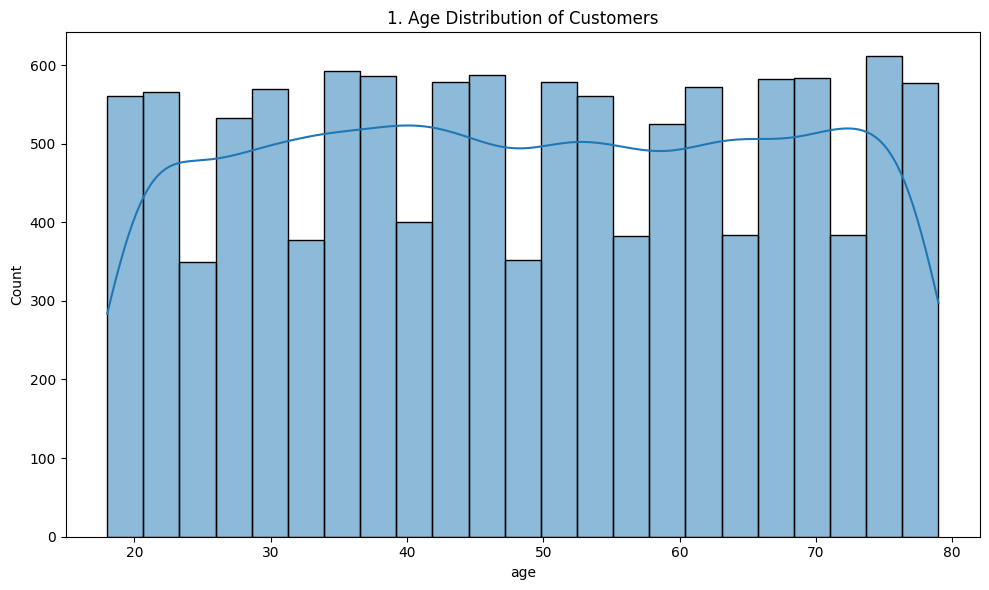

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['age'], kde=True)
plt.title(f'{plot_no}. Age Distribution of Customers')
show_fig()
plot_no += 1

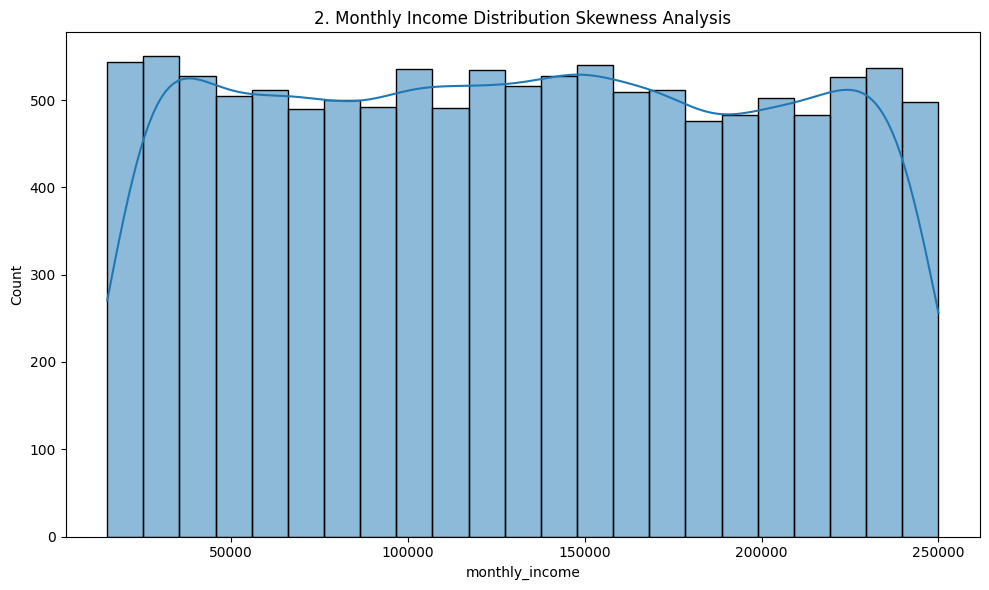

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['monthly_income'], kde=True)
plt.title(f'{plot_no}. Monthly Income Distribution Skewness Analysis')
show_fig()
plot_no += 1

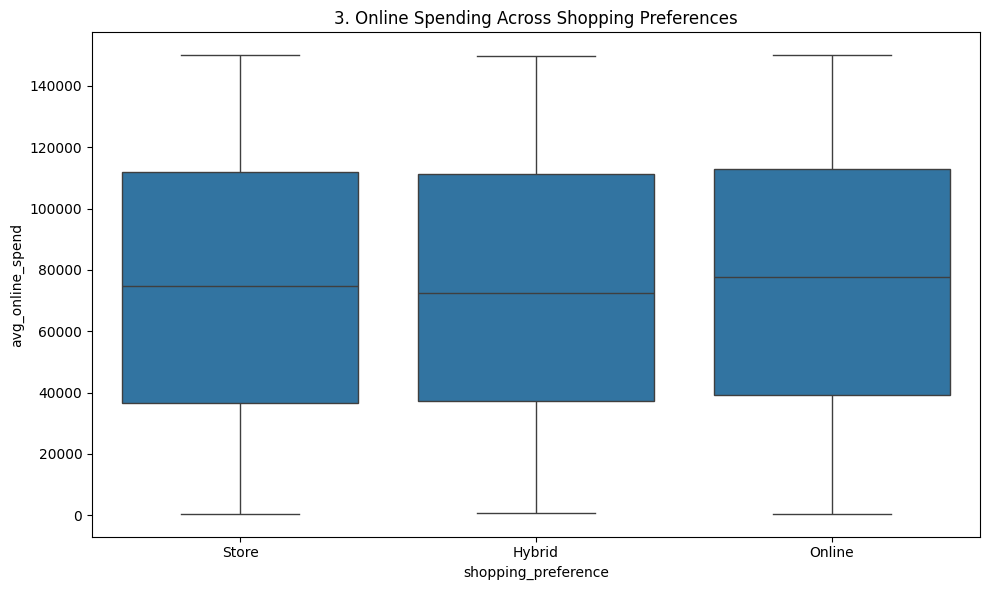

In [15]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='shopping_preference', y='avg_online_spend', data=df)
plt.title(f'{plot_no}. Online Spending Across Shopping Preferences')
show_fig()
plot_no += 1

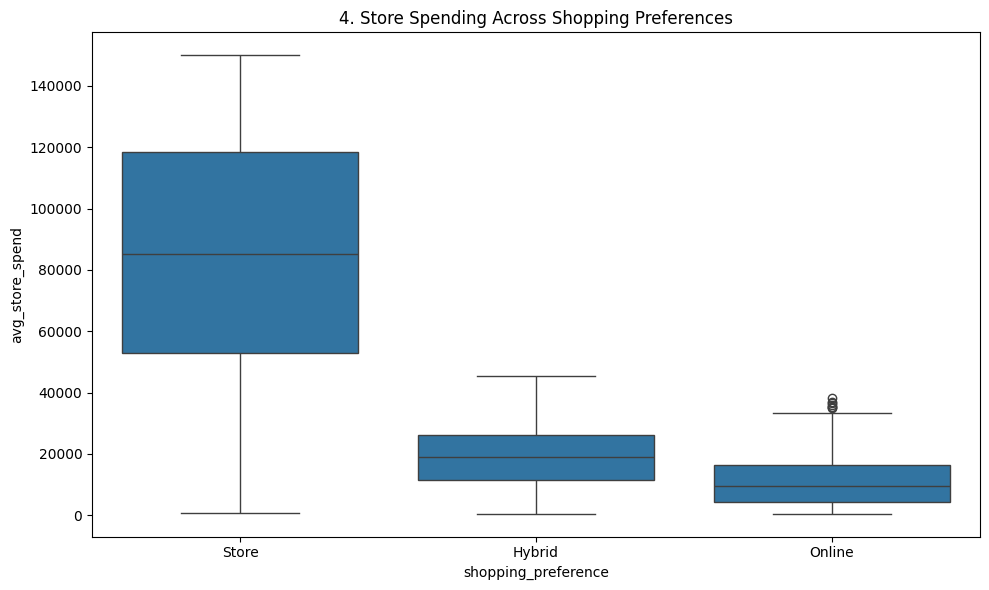

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='shopping_preference', y='avg_store_spend', data=df)
plt.title(f'{plot_no}. Store Spending Across Shopping Preferences')
show_fig()
plot_no += 1

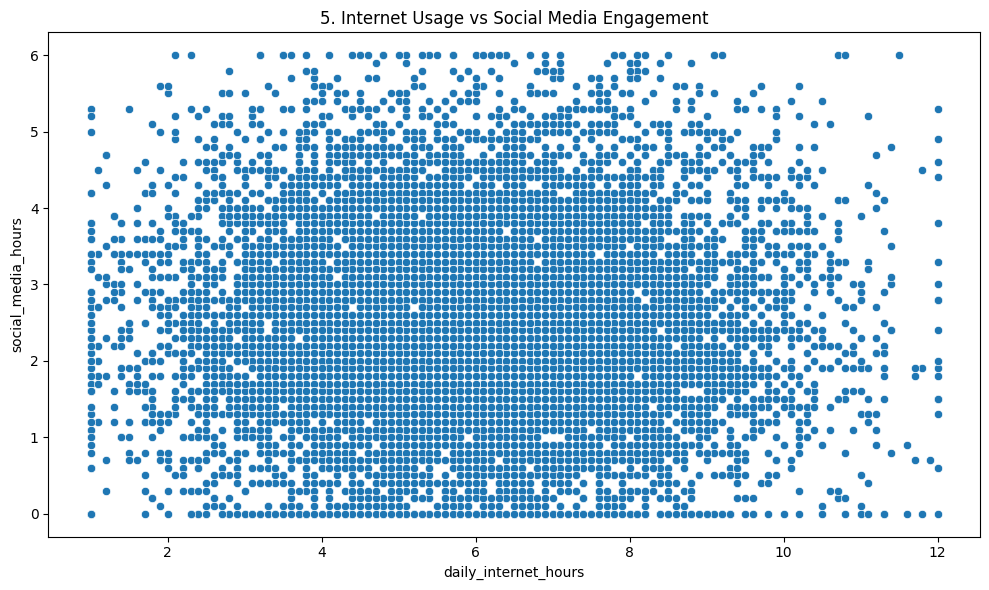

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='daily_internet_hours', y='social_media_hours', data=df)
plt.title(f'{plot_no}. Internet Usage vs Social Media Engagement')
show_fig()
plot_no += 1

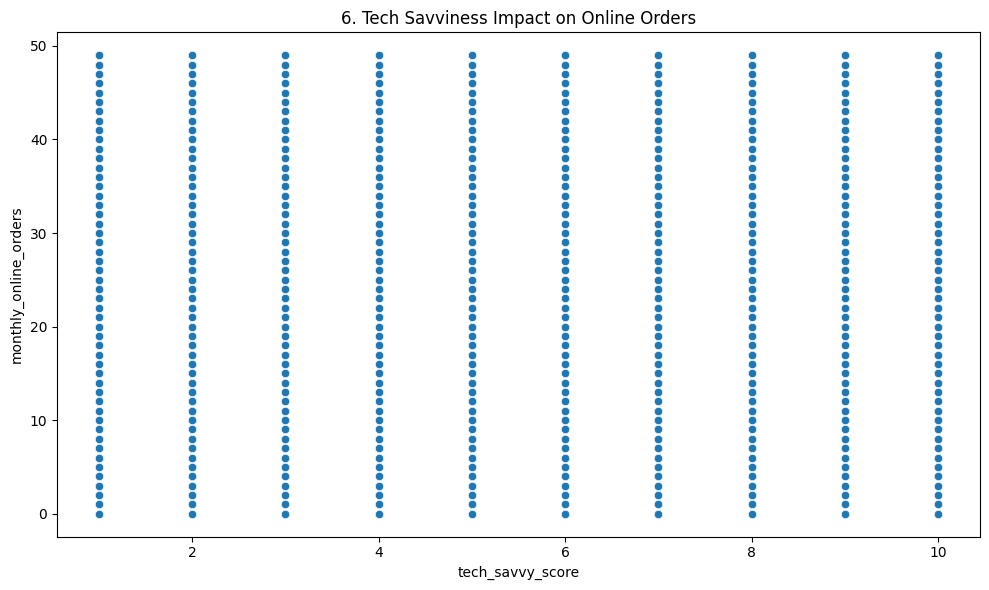

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='tech_savvy_score', y='monthly_online_orders', data=df)
plt.title(f'{plot_no}. Tech Savviness Impact on Online Orders')
show_fig()
plot_no += 1

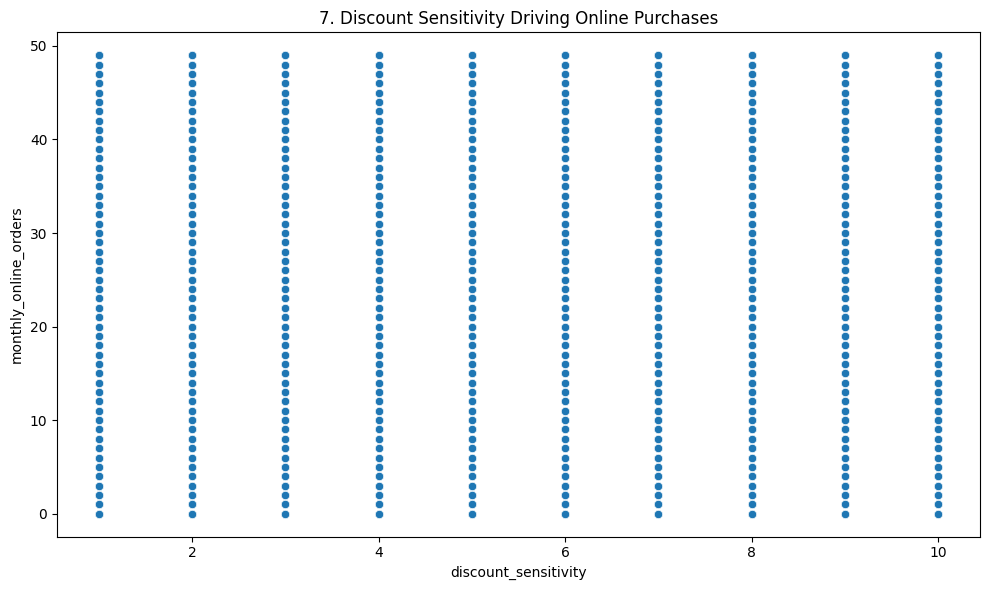

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='discount_sensitivity', y='monthly_online_orders', data=df)
plt.title(f'{plot_no}. Discount Sensitivity Driving Online Purchases')
show_fig()
plot_no += 1

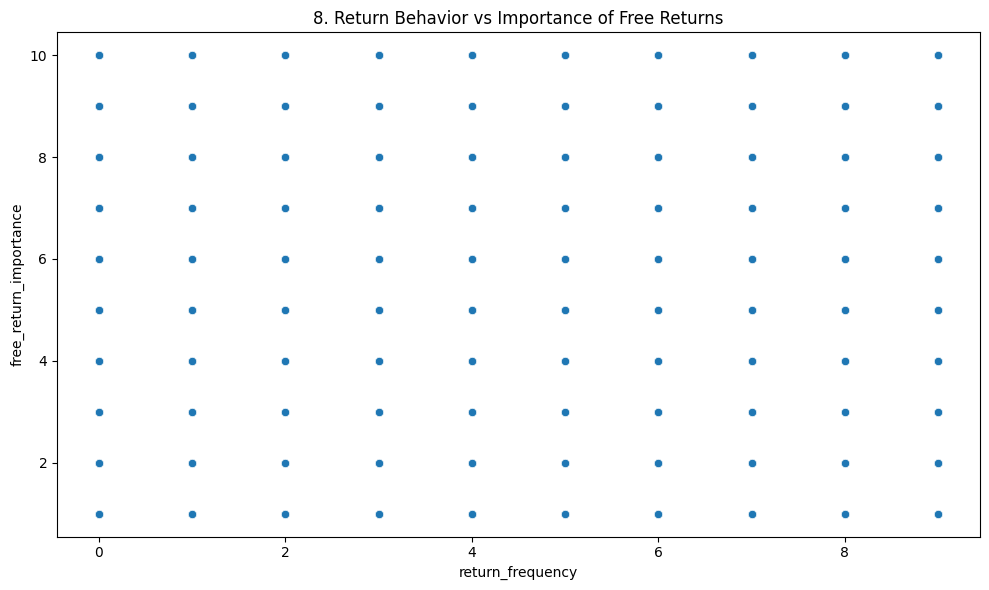

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='return_frequency', y='free_return_importance', data=df)
plt.title(f'{plot_no}. Return Behavior vs Importance of Free Returns')
show_fig()
plot_no += 1

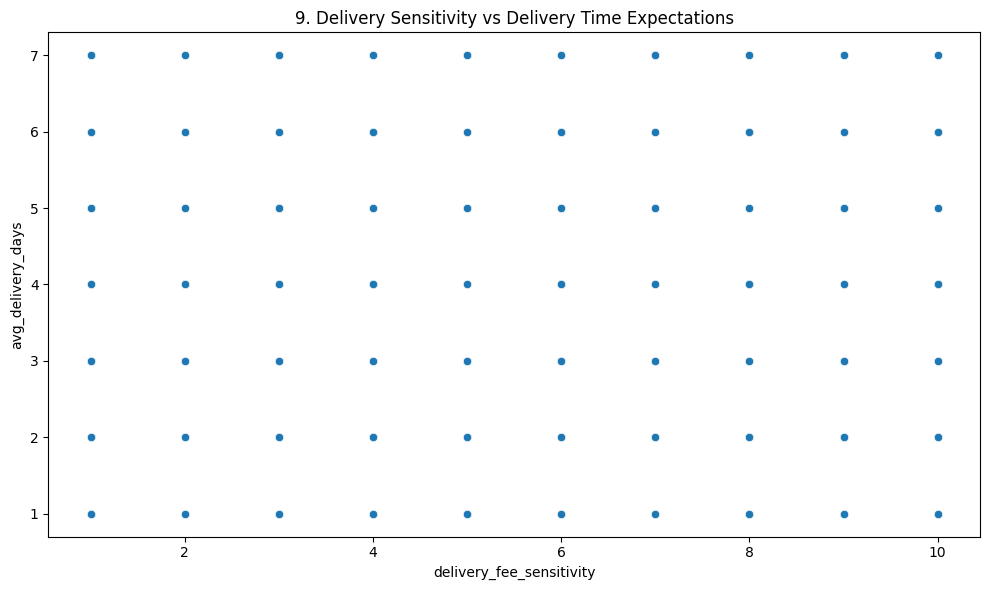

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='delivery_fee_sensitivity', y='avg_delivery_days', data=df)
plt.title(f'{plot_no}. Delivery Sensitivity vs Delivery Time Expectations')
show_fig()
plot_no += 1

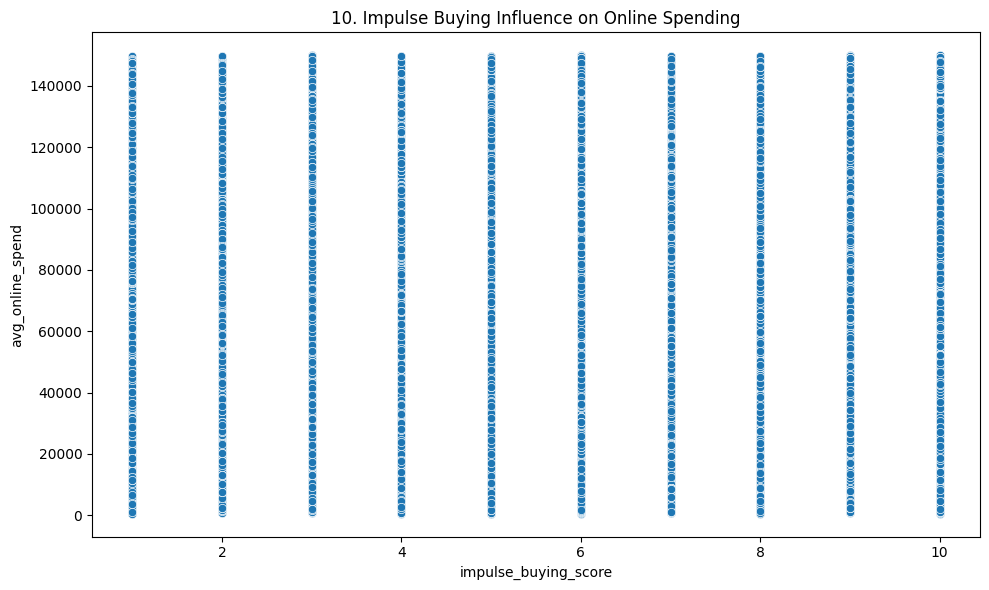

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='impulse_buying_score', y='avg_online_spend', data=df)
plt.title(f'{plot_no}. Impulse Buying Influence on Online Spending')
show_fig()
plot_no += 1

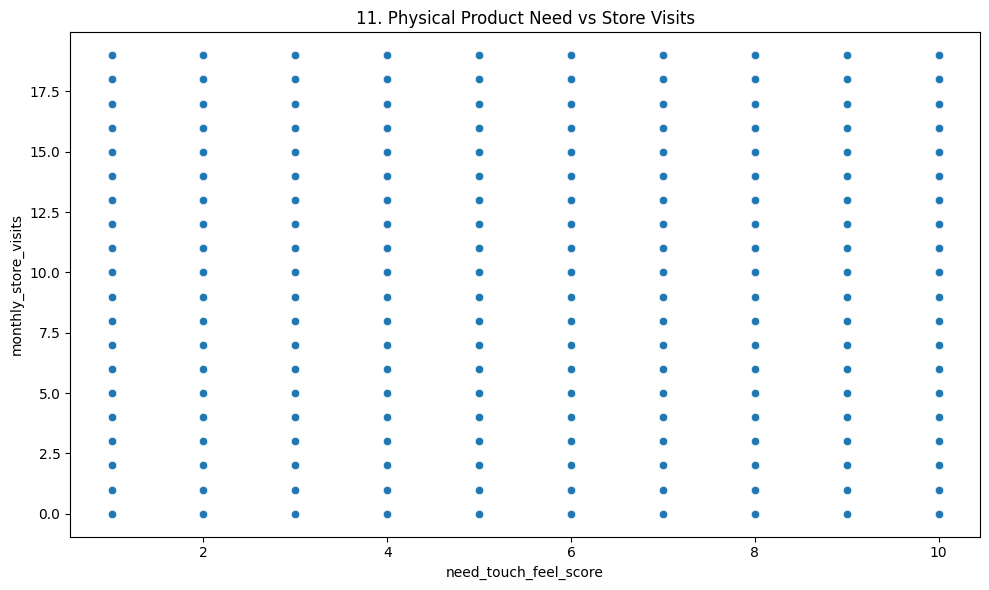

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='need_touch_feel_score', y='monthly_store_visits', data=df)
plt.title(f'{plot_no}. Physical Product Need vs Store Visits')
show_fig()
plot_no += 1

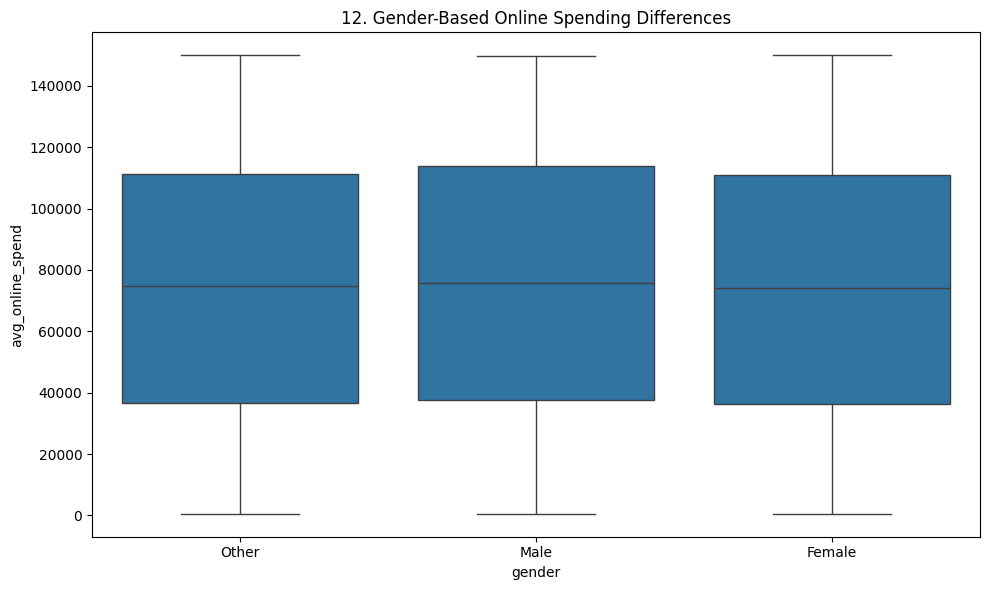

In [24]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='gender', y='avg_online_spend', data=df)
plt.title(f'{plot_no}. Gender-Based Online Spending Differences')
show_fig()
plot_no += 1

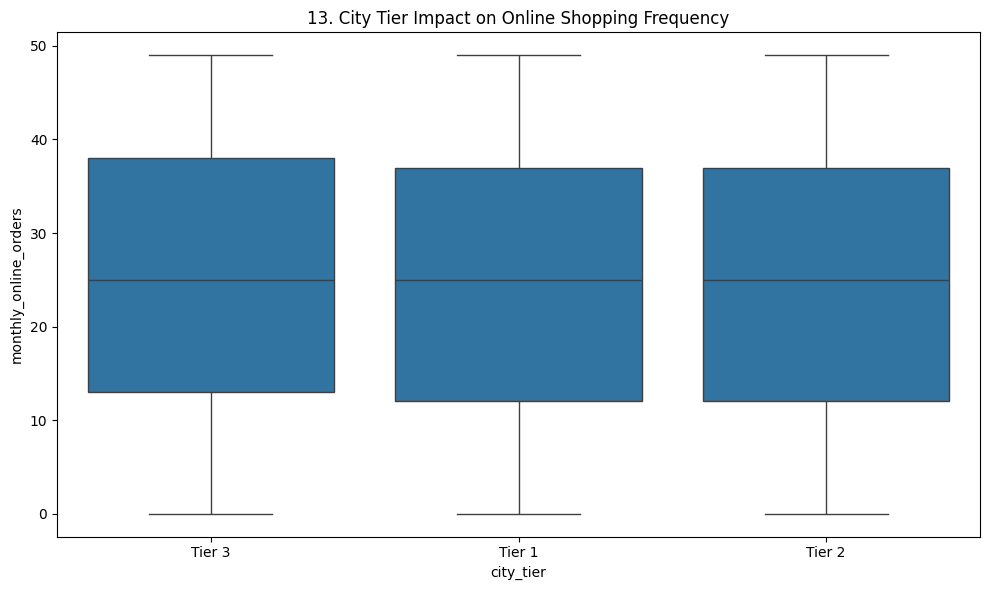

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='city_tier', y='monthly_online_orders', data=df)
plt.title(f'{plot_no}. City Tier Impact on Online Shopping Frequency')
show_fig()
plot_no += 1

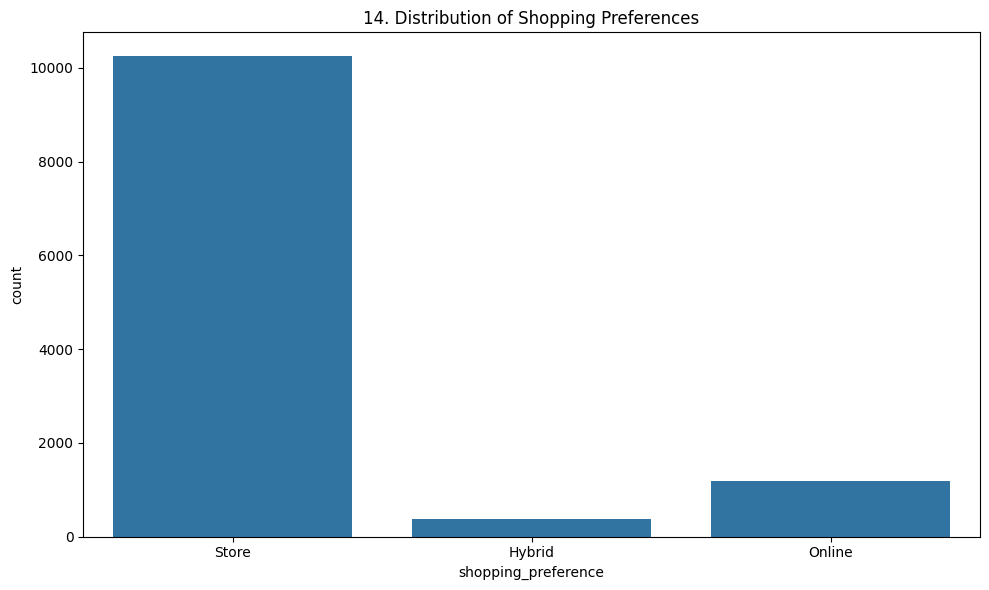

In [26]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='shopping_preference', data=df)
plt.title(f'{plot_no}. Distribution of Shopping Preferences')
show_fig()
plot_no += 1

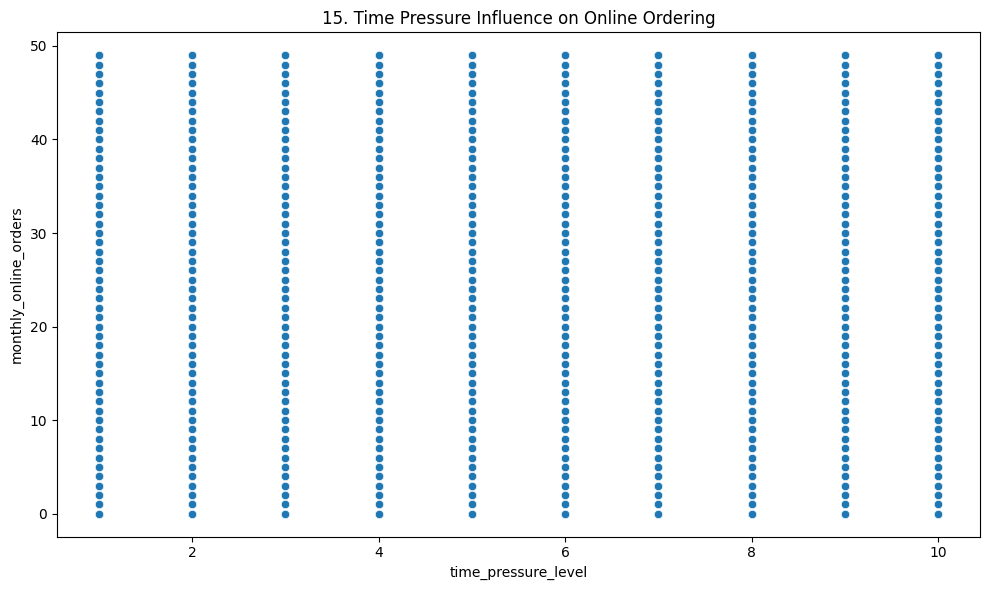

In [27]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='time_pressure_level', y='monthly_online_orders', data=df)
plt.title(f'{plot_no}. Time Pressure Influence on Online Ordering')
show_fig()
plot_no += 1

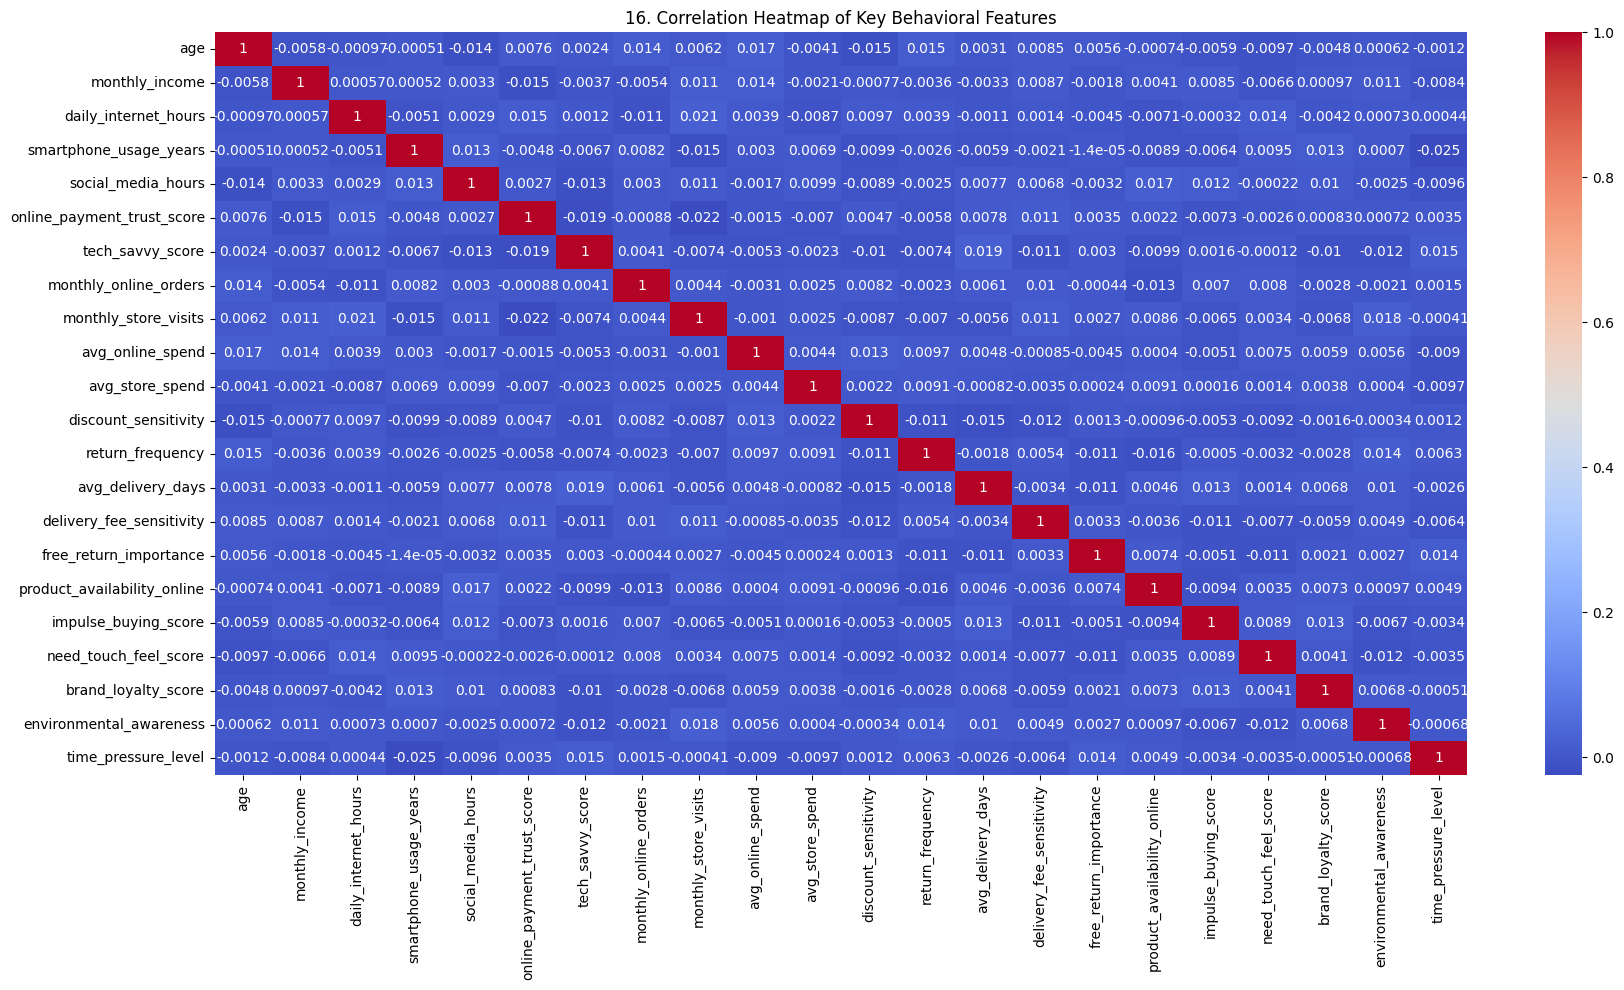

In [28]:
fig = plt.figure(figsize=(18, 10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=True)
plt.title(f'{plot_no}. Correlation Heatmap of Key Behavioral Features')
show_fig()
plot_no += 1

## Model Training

In [29]:
data = df.copy() ##copy dataframe to avoid modifying original

## encode categorical columns

In [30]:
le_gender = LabelEncoder()
le_city = LabelEncoder()
le_target = LabelEncoder()

data['gender'] = le_gender.fit_transform(data['gender'])
data['city_tier'] = le_city.fit_transform(data['city_tier'])
data['shopping_preference'] = le_target.fit_transform(data['shopping_preference'])

## split features and target

In [31]:
X = data.drop('shopping_preference', axis=1)
y = data['shopping_preference']

## split into train and test

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## scale features for better model performance

In [33]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## train SVM model (non-linear)

In [35]:
model = SVC(kernel='rbf')
model.fit(X_train, y_train)

SVC()

## make predictions

In [36]:
y_pred = model.predict(X_test)

## print accuracy score

In [38]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9592875318066157

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        72
           1       0.87      0.93      0.90       224
           2       0.97      1.00      0.98      2062

    accuracy                           0.96      2358
   macro avg       0.61      0.64      0.63      2358
weighted avg       0.93      0.96      0.94      2358

